In [1]:
import matplotlib.pyplot as plt
import dask.array as da
import dask_image.ndfilters
from skimage.measure import label
import tifffile
import skimage as ski
import pandas as pd
import os
import numpy as np
from scipy import ndimage as ndi
import segment_functions as fun
import foci_detection as fd
import importlib
importlib.reload(fun)
importlib.reload(fd)


<module 'foci_detection' from '/Users/hannahbolen/Desktop/image_analysis/whole_slide/foci_detection.py'>

In [33]:
# read in image
root = "/Users/hannahbolen/Desktop/image_analysis/"
img_name = "o8p_day7_s12.ome.tif"
img_path = os.path.join(root, img_name)
img = da.from_array(tifffile.imread(img_path))
# assign channels
nucleiChannel = img[0]
cy5Channel = img[1]
# constants -- display
ds = 10
H, W = nucleiChannel.shape
y0 = 14960 # underlying "tile" size of 512, make tile excerpt multiple of 512
x0 = 5460
# make tile from center of image
nucleiTile = nucleiChannel[y0:y0+600, x0:x0+600]
cy5Tile = cy5Channel[y0:y0+600, x0:x0+600]
# # make even smaller tile
nucleiZoom = nucleiTile[1000:3000, 2000:4000]
cy5Zoom = cy5Tile[1000:3000, 2000:4000]


In [39]:
# # read in image
# assign channels
FITC = 0
cy5 = 1
# constants -- display
ds = 10
H, W = img[FITC].shape
# make tile from center of image
y0 = H//2 - 5120 # underlying "tile" size of 512, make tile excerpt multiple of 512
x0 = W//2 - 5120

## tile parameters for day 24
# x0 = 10700
# y0 = 29500 # underlying "tile" size of 512, make tile excerpt multiple of 512
# # make tile from center of image -- tile for day24
# nucleiTile = img[FITC,y0:y0+1400, x0:x0+1400]
# cy5Tile = img[cy5, y0:y0+1400, x0:x0+1400]
# imgTile = img[:,y0:y0+1400, x0:x0+1400]

nucleiTile = img[FITC,y0:y0+5120, x0:x0+5120]
cy5Tile = img[cy5, y0:y0+5120, x0:x0+5120]
imgTile = img[:,y0:y0+5120, x0:x0+5120]
# make even smaller tile
nucleiZoom = nucleiTile[1000:3000, 2000:4000]
cy5Zoom = cy5Tile[1000:3000, 2000:4000]
imgZoom = imgTile[:,1000:3000, 2000:4000]

In [38]:
nucleiChannel.shape

(41653, 41653)

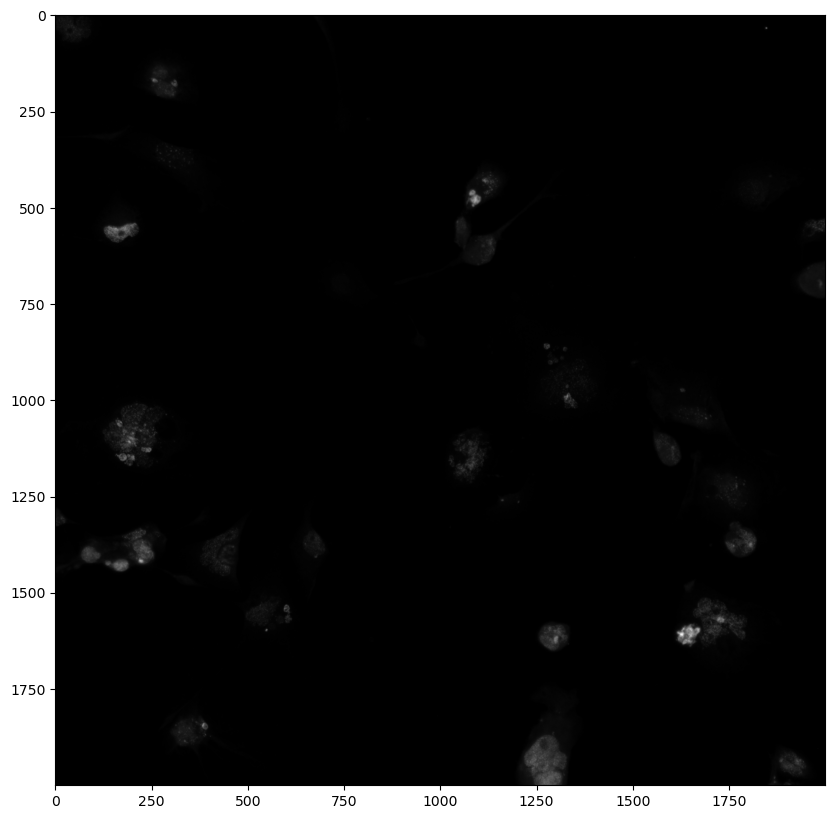

In [50]:
fig, ax = plt.subplots(figsize=(10,10))
ax.imshow(cy5Zoom, cmap="gray")

In [26]:
# constants -- processing
umPerPx = 0.325
nucleiThreshold = 50
nucleiMin = 150/umPerPx**2
nucleiMax = 12000
nucleiMean = 300/umPerPx**2
smooth=3
cy5_range = (256, 6000)
foci_radius = 5
foci_threshold = 50
# function to visualize
def visualize(base,base_title = "nuclei", clrs=[],**images):
    plt.figure(figsize = (18,18))
    plt.subplot(2, 3, 1)
    plt.axis('off')
    plt.imshow(base, cmap = "gray")
    plt.title(base_title)
    if len(clrs) == len(images):
        for i, img in enumerate(images.keys(), start=2):
            plt.subplot(2,3,i)
            plt.title(img)
            plt.imshow(images[img], cmap = clrs[i])
            plt.axis('off')
            plt.tight_layout()
    elif len(clrs) == 1:
        for i, img in enumerate(images.keys(), start=2):
            plt.subplot(2,3,i)
            plt.title(img)
            plt.imshow(images[img], cmap = clrs[0])
            plt.axis('off')
            plt.tight_layout()
    elif len(clrs) == 0:
        for i, img in enumerate(images.keys(), start=2):
            plt.subplot(2,3,i)
            plt.title(img)
            plt.imshow(images[img])
            plt.axis('off')
            plt.tight_layout()
    else:
        return("Error - incompatible cmap provided")
    plt.show()

In [41]:
importlib.reload(fun)
fun.OPS_PROFILE = True
fun.OPS_PROFILE_VERBOSE = True
fun.ops_timing_reset()
nucleiArgs = dict(threshold=lambda x: nucleiThreshold, 
            area_min=nucleiMin, area_max=nucleiMax,
            smooth=smooth)
findNuclei = fun.find_nuclei(nucleiTile, **nucleiArgs)
fun.ops_timing_summary()

featuresDict = {"foci"}

[ops_timer] simple_binary: 0.565s
[ops_timer] label: 0.042s
[ops_timer] filter_by_region_initial: 0.273s
[ops_timer] fill_holes: 0.323s
[ops_timer] label_hole_diff: 0.043s
[ops_timer] filter_by_region_holes: 0.269s
[ops_timer] apply_hole_fill: 0.001s
[ops_timer] watershed: 2.318s
[ops_timer] filter_by_region_final: 0.257s


In [42]:
threshold = 7
mask = ski.util.img_as_ubyte(ski.filters.gaussian(nucleiTile, sigma = 1.8)) >= threshold
mask = ski.morphology.remove_small_objects(mask, min_size=nucleiMin)
labeled = ski.measure.label(mask)
labeled = fun.filter_by_region(labeled, threshold=lambda x: nucleiThreshold, intensity_image=nucleiTile) > 0
filled = ndi.binary_fill_holes(labeled)
difference = ski.measure.label(filled != labeled)
change = fun.filter_by_region(difference, score=lambda r: r.area < nucleiMin, threshold=0) > 0
labeled[change] = filled[change]
nuclei = fun.apply_watershed(labeled,smooth=4)
result = fun.filter_by_region(nuclei, score=lambda r: nucleiMin < r.area < nucleiMax, threshold=nucleiThreshold)
boundaries = ski.segmentation.mark_boundaries(ski.exposure.rescale_intensity(nucleiTile,in_range = (256, 12000)), result, mode="thick")

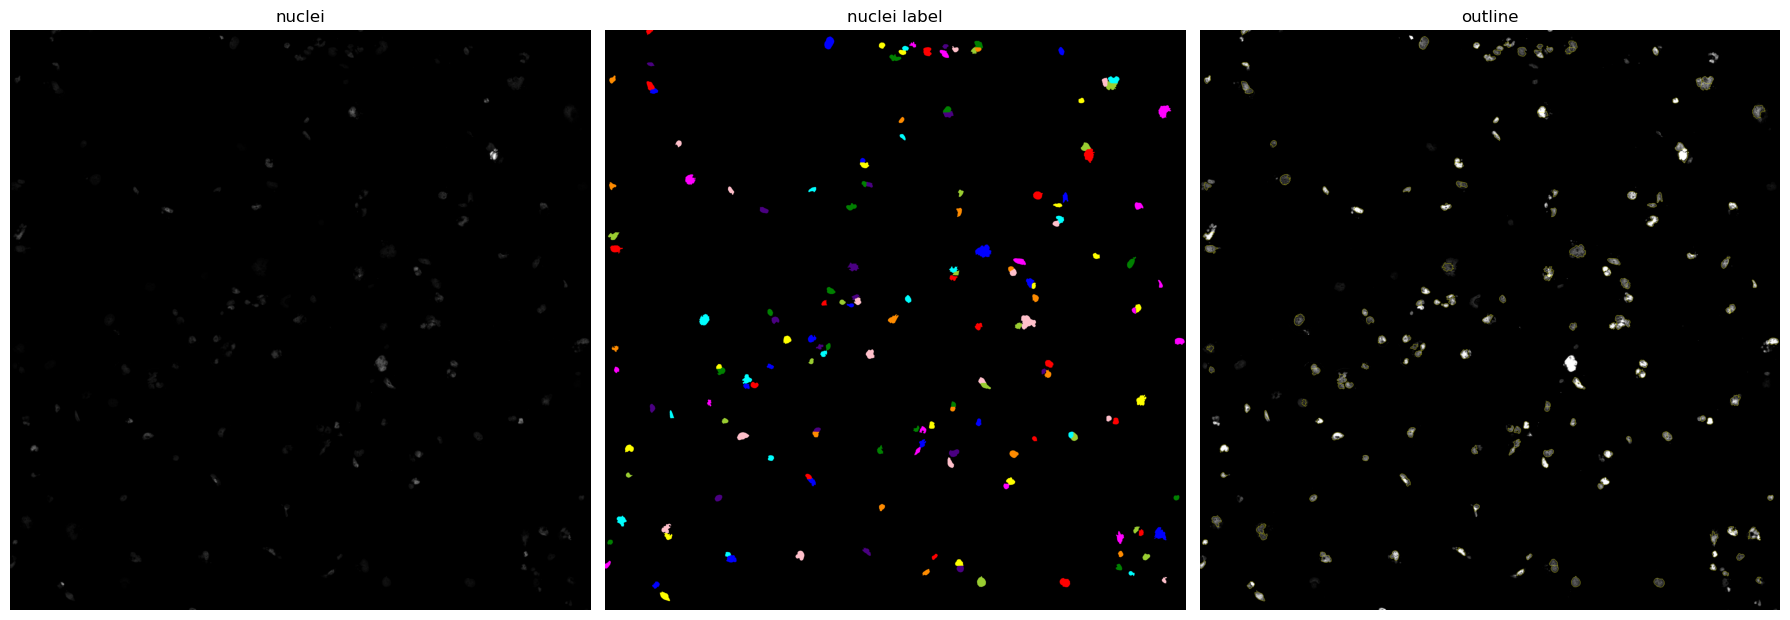

In [43]:
#boundaries = ski.segmentation.mark_boundaries(ski.exposure.rescale_intensity(nucleiTile,in_range = (256, 12000)), findNuclei, mode="thick")
images = {"nuclei label":ski.color.label2rgb(result), "outline":boundaries}
visualize(nucleiTile,**images)

In [ ]:
def log_ndi(data, sigma=1, *args, **kwargs):
    """Apply Laplacian of Gaussian to each image in a stack of shape (..., I, J).

    Args:
        data (numpy.ndarray): Input data.
        sigma (float, optional): Standard deviation of the Gaussian kernel. Default is 1.
        *args: Additional positional arguments passed to scipy.ndimage.filters.gaussian_laplace.
        **kwargs: Additional keyword arguments passed to scipy.ndimage.filters.gaussian_laplace.

    Returns:
        numpy.ndarray: Resulting images after applying Laplacian of Gaussian.
    """
    # Define the Laplacian of Gaussian filter function
    f = ndi.filters.gaussian_laplace

    # Apply the filter to the data and invert the output
    arr_ = -1 * f(data.astype(float), sigma, *args, **kwargs)

    # Clip values to ensure they are within the valid range [0, 65535] and convert back to uint16
    arr_ = np.clip(arr_, 0, 65535) / 65535

    # Suppress precision warning from skimage
    return ski.img_as_uint(arr_)
    
def find_foci(data, radius=3, threshold=10, remove_border_foci):
    """Detect foci in the given image using a white tophat filter and other processing steps.

    Args:
        data (numpy.ndarray): Input image data.
        radius (int, optional): Radius of the disk used in the white tophat filter. Default is 3.
        threshold (float, optional): Threshold value for identifying foci in the processed image. Default is 10.
        remove_border_foci (bool, optional): Flag to remove foci touching the image border. Default is False.

    Returns:
        labeled (numpy.ndarray): Labeled segmentation mask of foci.
    """
    # Apply white tophat filter to highlight foci
    tophat = ski.morphology.white_tophat(
        data, footprint=ski.morphology.disk(radius)
    )

    # Apply Laplacian of Gaussian to the filtered image
    tophat_log = log_ndi(tophat, sigma=radius)

    # Threshold the image to create a binary mask
    mask = tophat_log > threshold

    # Remove small objects from the mask
    mask = ski.morphology.remove_small_objects(mask, min_size=(radius**2))

    # Label connected components in the mask
    labeled = ski.measure.label(mask)

    # Apply watershed algorithm to refine segmentation
    labeled = fun.apply_watershed(labeled, smooth=1)

    if remove_border_foci:
        # Remove foci touching the border
        border_mask = data > 0
        labeled = remove_border(labeled, ~border_mask)

    return labeled


In [53]:
foci = find_foci(cy5Zoom)

/var/folders/0z/cjqt0cf96g16c0wxg68l427w0000gn/T/ipykernel_41465/1704754078.py:14: DeprecationWarning: Please import `gaussian_laplace` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  f = ndi.filters.gaussian_laplace


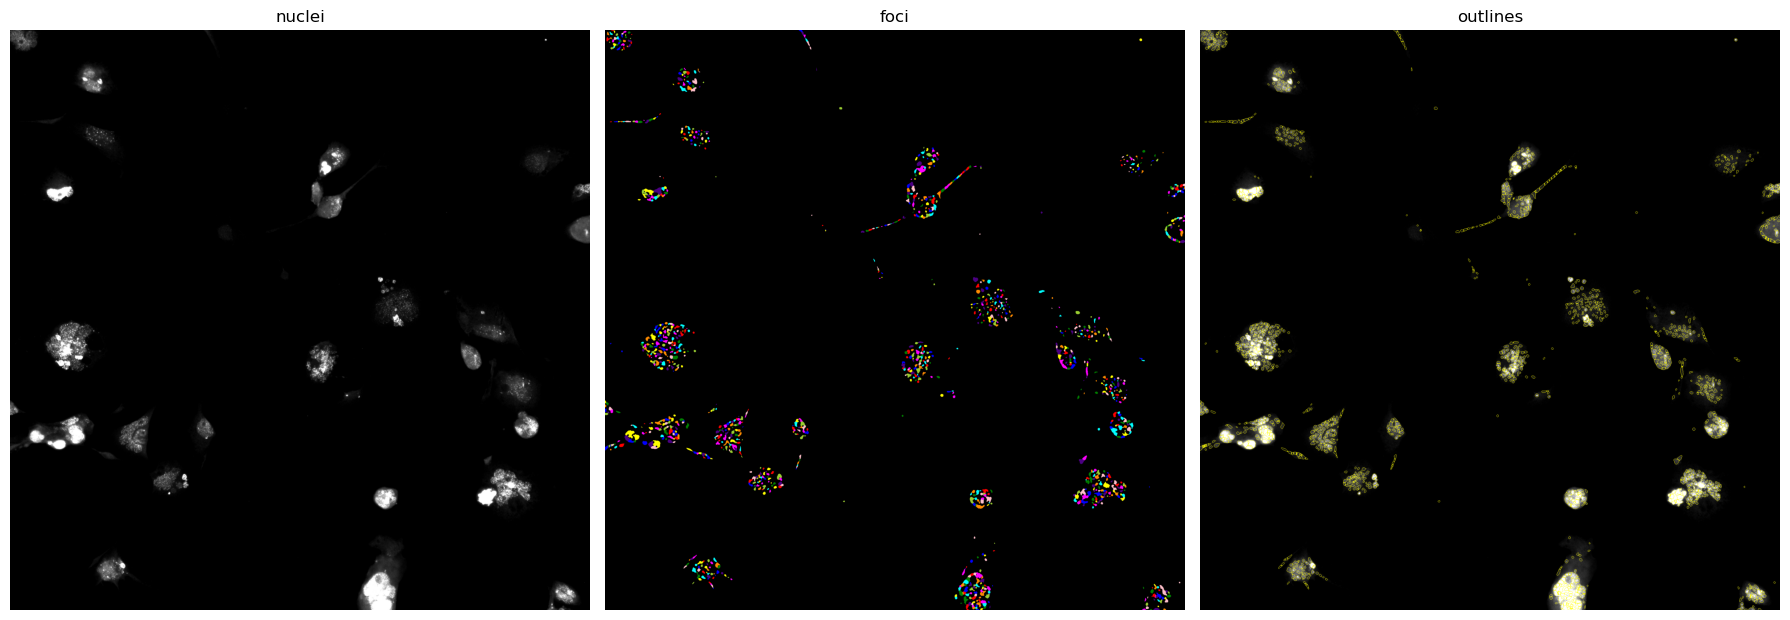

In [55]:
visualize(ski.exposure.rescale_intensity(cy5Zoom, in_range=cy5_range), **{"foci":ski.color.label2rgb(foci), "outlines":ski.segmentation.mark_boundaries(ski.exposure.rescale_intensity(cy5Zoom,in_range = cy5_range), foci)})

/var/folders/0z/cjqt0cf96g16c0wxg68l427w0000gn/T/ipykernel_41465/1704754078.py:14: DeprecationWarning: Please import `gaussian_laplace` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  f = ndi.filters.gaussian_laplace


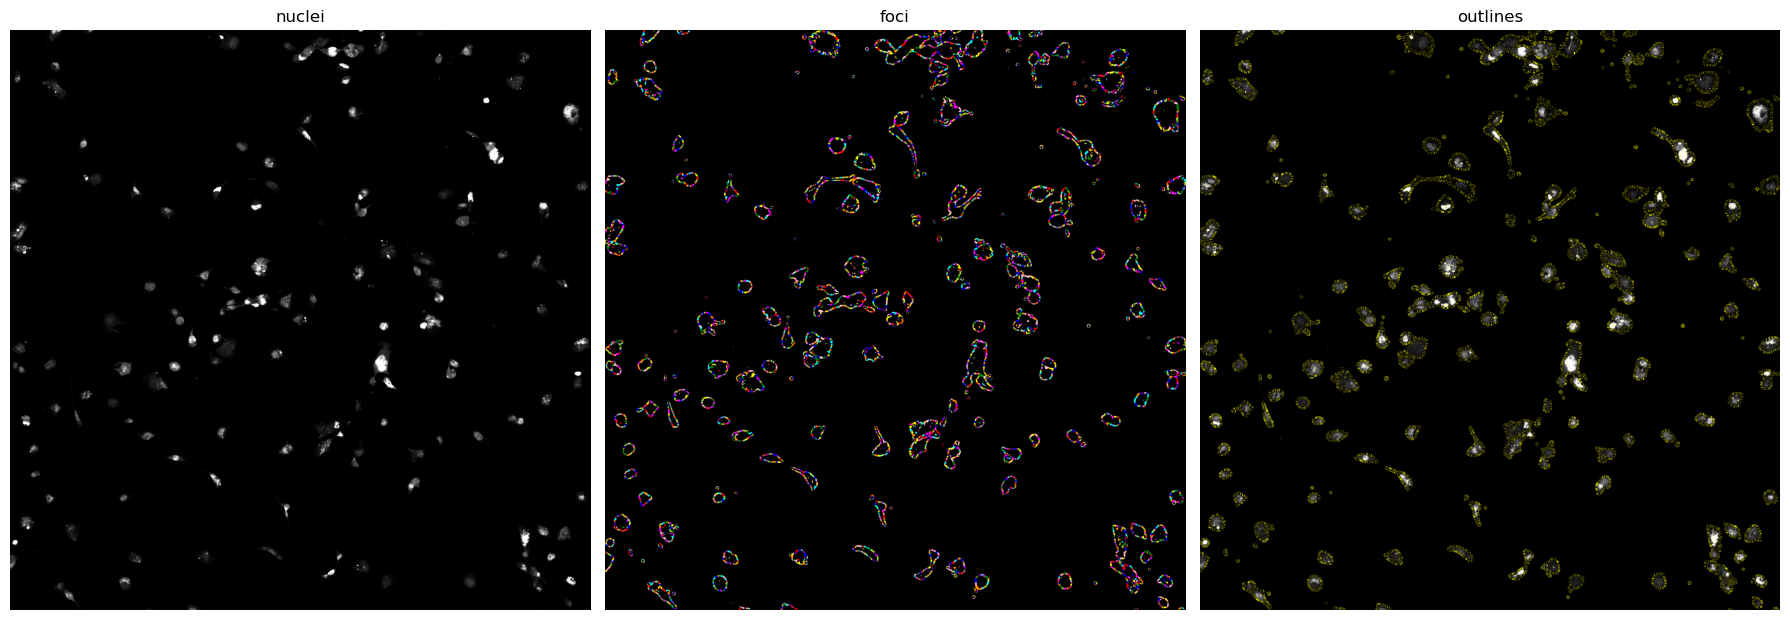

In [52]:
radius = 5
tophat = ski.morphology.white_tophat(
        cy5Tile, footprint=ski.morphology.disk(radius)
    )
 # Apply Laplacian of Gaussian to the filtered image
tophat_log = log_ndi(tophat, sigma=radius)

# threshold image to create binary mask
mask = tophat_log>50
# Remove small objects from the mask
mask = ski.morphology.remove_small_objects(mask, min_size=(radius**2))

# Label connected components in the mask
labeled = ski.measure.label(mask)

# Apply watershed algorithm to refine segmentation
foci = fun.apply_watershed(labeled, smooth=1)
visualize(ski.exposure.rescale_intensity(cy5Tile, in_range=cy5_range), **{"foci":ski.color.label2rgb(foci), "outlines":ski.segmentation.mark_boundaries(ski.exposure.rescale_intensity(cy5Tile,in_range = cy5_range), foci)})


In [10]:
visualize(ski.exposure.rescale_intensity(cy5Zoom, in_range=cy5_range), **{"foci":ski.color.label2rgb(foci), "outlines":ski.segmentation.mark_boundaries(ski.exposure.rescale_intensity(cy5Zoom,in_range = cy5_range), foci)})

NameError: name 'cy5Zoom' is not defined

In [19]:
visualize(ski.exposure.rescale_intensity(cy5Zoom, in_range=cy5_range), **{"foci":ski.color.label2rgb(foci), "outlines":ski.segmentation.mark_boundaries(ski.exposure.rescale_intensity(cy5Zoom,in_range = cy5_range), foci)})

IndexError: boolean index did not match indexed array along axis 0; size of axis is 0 but size of corresponding boolean axis is 600

In [20]:
importlib.reload(fun)
fun.OPS_PROFILE = True
fun.OPS_PROFILE_VERBOSE = True
fun.ops_timing_reset()
kwargs = dict(threshold=lambda x: nucleiThreshold, 
            area_min=nucleiMin, area_max=nucleiMax,
            smooth=smooth)
findNuclei = fun.find_nuclei(nucleiChannel, **kwargs)
fun.ops_timing_summary()

[ops_timer] simple_binary: 9.808s
[ops_timer] label: 0.743s
[ops_timer] filter_by_region_initial: 5.127s
[ops_timer] fill_holes: 7.690s
[ops_timer] label_hole_diff: 0.739s
[ops_timer] filter_by_region_holes: 4.891s
[ops_timer] apply_hole_fill: 0.032s
[ops_timer] watershed: 33.962s
[ops_timer] filter_by_region_final: 4.443s


['watershed                  33.962s   50.4%\n',
 'simple_binary               9.808s   14.5%\n',
 'fill_holes                  7.690s   11.4%\n',
 'filter_by_region_initial    5.127s    7.6%\n',
 'filter_by_region_holes      4.891s    7.3%\n',
 'filter_by_region_final      4.443s    6.6%\n',
 'label                       0.743s    1.1%\n',
 'label_hole_diff             0.739s    1.1%\n',
 'apply_hole_fill             0.032s    0.0%\n',
 'total                      67.435s  100.0%\n']

In [21]:
boundaries = ski.segmentation.mark_boundaries(ski.exposure.rescale_intensity(nucleiChannel,in_range = (256, 12000)), findNuclei, mode="thick")
images = {"findNuclei":ski.color.label2rgb(findNuclei), "outline":boundaries}
visualize(nucleiZoom,**images)

KeyboardInterrupt: 

In [ ]:
def simple_binary(image, min_size, sigma = 1.8, global_threshold = 7):
    mask = ski.util.img_as_ubyte(dask_image.ndfilters.gaussian(image, sigma)) >= global_threshold
    mask = ski.morphology.remove_small_objects(mask, min_size)
    return mask

In [ ]:
maybe = simple_binary(nuclei, nucleiMin)